<a href="https://colab.research.google.com/github/Mohommad-Nuzlan-GH/M-R-M-Nuzlan-Database-Analytics-Top-Up-2026/blob/main/3_R_Analytics_NS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#1 Install required R packages
install.packages("ggplot2")
install.packages("dplyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
#2 Load required libraries
library(ggplot2)
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [3]:
#3 Load cleaned datasets
CUSTOMER <- read.csv("1#clean_customers.csv")
ORDER_DATA <- read.csv("3#clean_orders.csv")
COMPLAINT <- read.csv("4#clean_complaints.csv")
DELIVERY <- read.csv("5#clean_deliveries.csv")
DRIVER <- read.csv("6#clean_drivers.csv")
VEHICLE <- read.csv("7#clean_vehicles.csv")
HUB <- read.csv("8#clean_hubs.csv")
INCIDENT <- read.csv("9#clean_incidents.csv")

In [4]:
#4 Check key datasets
head(DELIVERY)
head(COMPLAINT)
head(HUB)

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_duration_hours,failed_delivery_flag,delayed_delivery_flag
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>
1,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2026-04-28 05:59:54,Failed,17.26,1,0,3.07,12.05,16291.05,1,0
2,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,,Ontime,10.34,1,0,5.00,13.41,NA,0,0
3,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,,Ontime,7.92,0,0,4.98,8.51,NA,0,0
4,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,,Delayed,16.42,0,0,4.18,13.62,NA,0,1
5,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,,Ontime,14.52,1,0,4.18,9.22,NA,0,0
6,DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2026-04-28 11:52:24,Delayed,13.84,0,0,1.57,9.58,14255.21,0,1


,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount,is_resolved
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>
1,CP0001,C0464,O00814,Appissue,App,High,2025-03-30 02:36:00,Open,11,23.99,0
2,CP0002,C0056,O00628,Missedpickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64,0
3,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41,0
4,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,Awaitingcustomer,7,23.44,0
5,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18,1
6,CP0006,C0096,O00147,Delay,App,Medium,2024-07-22 07:43:00,Resolved,9,18.51,1


,hub_id,hub_name,zone,hub_type,capacity_score,capacity_category
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>
1,H01,North Exchange,North,Dispatch,82,High
2,H02,South Link,South,Dispatch,78,High
3,H03,East Dock,East,Warehouse,74,Medium
4,H04,West Gate,West,Dispatch,69,Medium
5,H05,Central Core,Central,Control,88,High
6,H06,Airport Hub,Airport,Dispatch,71,Medium


Insight: Most deliveries are on time, but delayed and failed deliveries still form a meaningful share of total operations.
This supports the case study issue that NorthStar is facing service reliability problems.


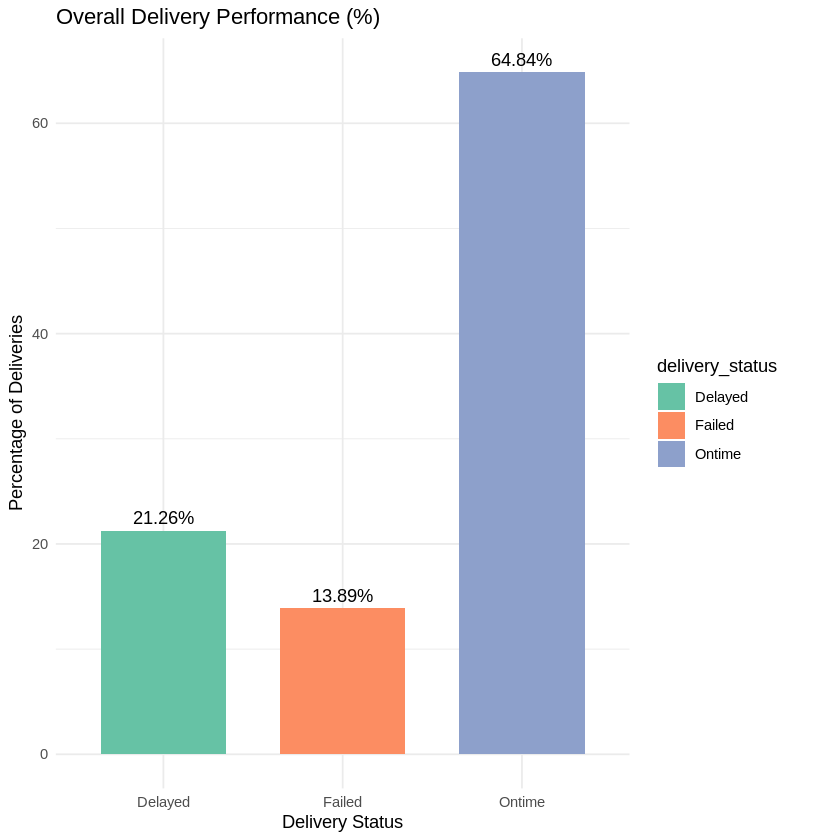

In [5]:
#-----------GRAPH 1 — DELIVERY PERFORMANCE OVERVIEW (KPI LEVEL)---------------------

#1 Create delivery KPI summary with percentages
delivery_kpi <- DELIVERY %>%
  group_by(delivery_status) %>%
  summarise(total = n()) %>%
  mutate(percentage = round(100 * total / sum(total), 2))

#2 Plot delivery performance distribution
p1 <- ggplot(delivery_kpi, aes(x = delivery_status, y = percentage, fill = delivery_status)) +
  geom_bar(stat = "identity", width = 0.7) +
  geom_text(aes(label = paste0(percentage, "%")), vjust = -0.5) +
  scale_fill_brewer(palette = "Set2") +
  labs(
    title = "Overall Delivery Performance (%)",
    x = "Delivery Status",
    y = "Percentage of Deliveries"
  ) +
  theme_minimal()

#3 Display graph
p1

#4 Print insight
cat("Insight: Most deliveries are on time, but delayed and failed deliveries still form a meaningful share of total operations.\n")
cat("This supports the case study issue that NorthStar is facing service reliability problems.\n")

Insight: Some hubs show higher failure rates than others, meaning performance problems are not evenly distributed.
This supports the case study concern that certain city zones and hubs perform worse than others.


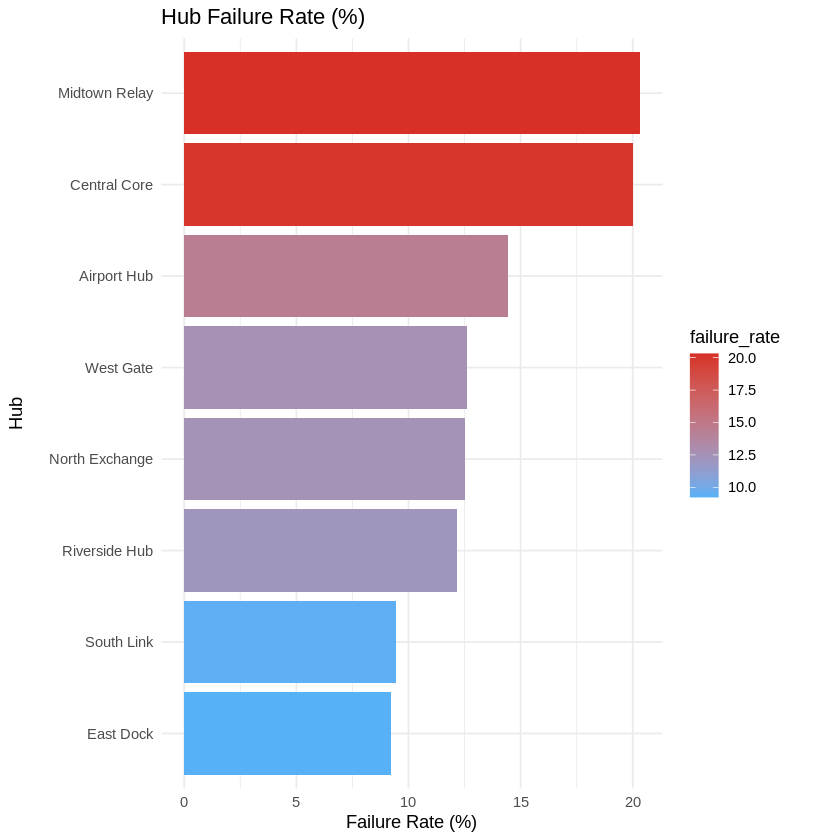

In [6]:
#----------------GRAPH 2 — HUB FAILURE RATE (KEY PROBLEM AREAS)---------------------

#1 Calculate failure rate per hub
hub_kpi <- DELIVERY %>%
  inner_join(HUB, by = "hub_id") %>%
  group_by(hub_name) %>%
  summarise(
    total = n(),
    failed = sum(delivery_status == "Failed"),
    failure_rate = round(100 * failed / total, 2)
  ) %>%
  arrange(desc(failure_rate))

#2 Plot hub failure rate
p2 <- ggplot(hub_kpi, aes(x = reorder(hub_name, failure_rate), y = failure_rate, fill = failure_rate)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  scale_fill_gradient(low = "#56B1F7", high = "#D73027") +
  labs(
    title = "Hub Failure Rate (%)",
    x = "Hub",
    y = "Failure Rate (%)"
  ) +
  theme_minimal()

#3 Display graph
p2

#4 Print insight
cat("Insight: Some hubs show higher failure rates than others, meaning performance problems are not evenly distributed.\n")
cat("This supports the case study concern that certain city zones and hubs perform worse than others.\n")

Insight: A small group of drivers are linked to higher numbers of delayed or failed deliveries.
This may indicate driver-level performance differences, training gaps, or route handling issues.


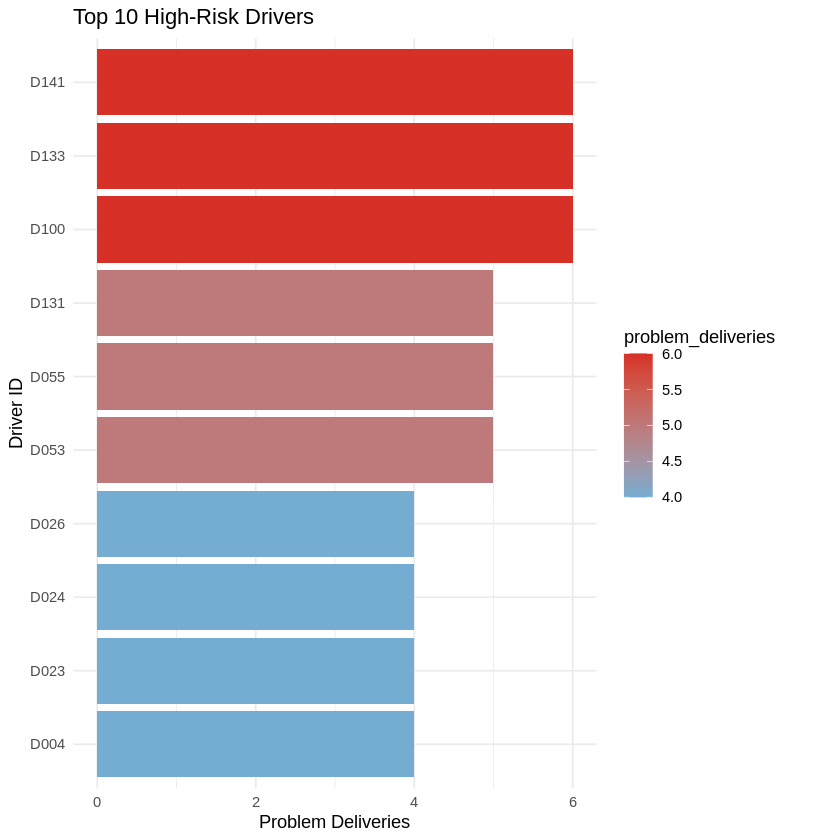

In [7]:
#-----------------GRAPH 3 — DRIVER RISK ANALYSIS (PROBLEM DRIVERS)------------------

#1 Identify high-risk drivers
driver_risk <- DELIVERY %>%
  filter(delivery_status %in% c("Delayed", "Failed")) %>%
  group_by(driver_id) %>%
  summarise(problem_deliveries = n()) %>%
  arrange(desc(problem_deliveries)) %>%
  head(10)

#2 Plot driver risk
p3 <- ggplot(driver_risk, aes(x = reorder(driver_id, problem_deliveries), y = problem_deliveries, fill = problem_deliveries)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  scale_fill_gradient(low = "#74ADD1", high = "#D73027") +
  labs(
    title = "Top 10 High-Risk Drivers",
    x = "Driver ID",
    y = "Problem Deliveries"
  ) +
  theme_minimal()

#3 Display graph
p3

#4 Print insight
cat("Insight: A small group of drivers are linked to higher numbers of delayed or failed deliveries.\n")
cat("This may indicate driver-level performance differences, training gaps, or route handling issues.\n")

Insight: Some complaint types occur more often and also create higher compensation costs.
This shows that service problems affect both customer satisfaction and business cost.


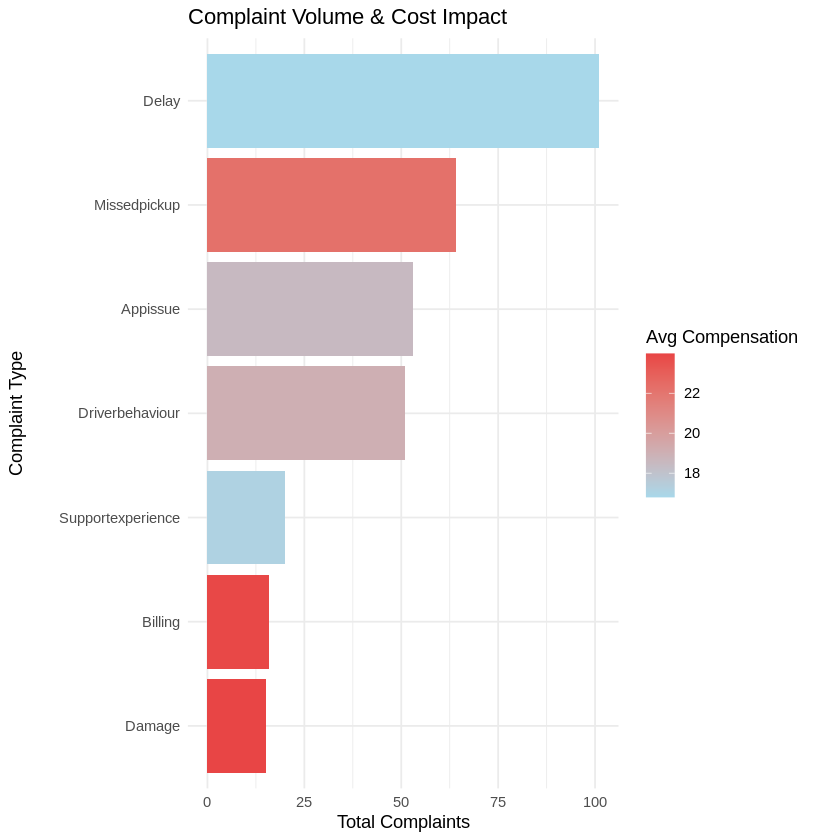

In [8]:
#-----------------GRAPH 4 — COMPLAINT IMPACT (BUSINESS COST)------------------------

#1 Complaint cost analysis
complaint_kpi <- COMPLAINT %>%
  group_by(complaint_type) %>%
  summarise(
    total = n(),
    avg_comp = round(mean(compensation_amount, na.rm = TRUE), 2)
  ) %>%
  arrange(desc(total))

#2 Plot complaint impact
p4 <- ggplot(complaint_kpi, aes(x = reorder(complaint_type, total), y = total, fill = avg_comp)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  scale_fill_gradient(low = "#a8d8ea", high = "#e84545") +
  labs(
    title = "Complaint Volume & Cost Impact",
    x = "Complaint Type",
    y = "Total Complaints",
    fill = "Avg Compensation"
  ) +
  theme_minimal()

#3 Display graph
p4

#4 Print insight
cat("Insight: Some complaint types occur more often and also create higher compensation costs.\n")
cat("This shows that service problems affect both customer satisfaction and business cost.\n")

Insight: Delivery failure rate differs by vehicle maintenance status.
This suggests vehicle condition may be one factor contributing to failed deliveries and service disruption.


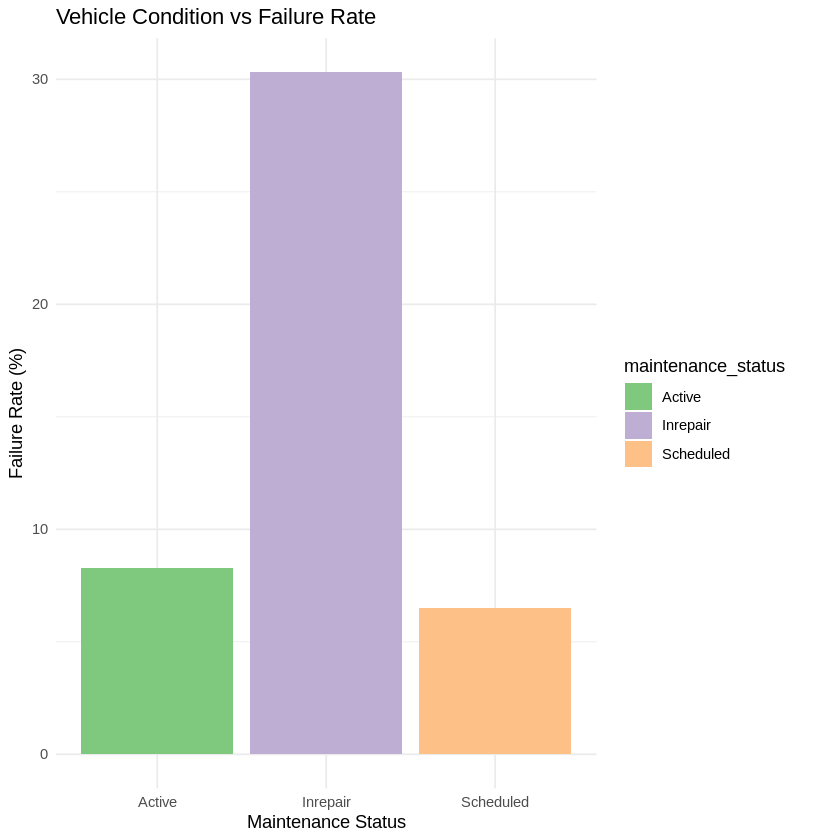

In [9]:
#---------------------GRAPH 5 — VEHICLE CONDITION VS FAILURE RATE------------------------

#1 Vehicle failure relationship
vehicle_kpi <- DELIVERY %>%
  inner_join(VEHICLE, by = "vehicle_id") %>%
  group_by(maintenance_status) %>%
  summarise(
    total = n(),
    failed = sum(delivery_status == "Failed"),
    failure_rate = round(100 * failed / total, 2)
  )

#2 Plot vehicle impact
p5 <- ggplot(vehicle_kpi, aes(x = maintenance_status, y = failure_rate, fill = maintenance_status)) +
  geom_bar(stat = "identity") +
  scale_fill_brewer(palette = "Accent") +
  labs(
    title = "Vehicle Condition vs Failure Rate",
    x = "Maintenance Status",
    y = "Failure Rate (%)"
  ) +
  theme_minimal()

#3 Display graph
p5

#4 Print insight
cat("Insight: Delivery failure rate differs by vehicle maintenance status.\n")
cat("This suggests vehicle condition may be one factor contributing to failed deliveries and service disruption.\n")

Insight: Incident severity is connected with delivery outcomes, especially delayed and failed deliveries.
This shows that operational incidents are important when explaining service disruption.


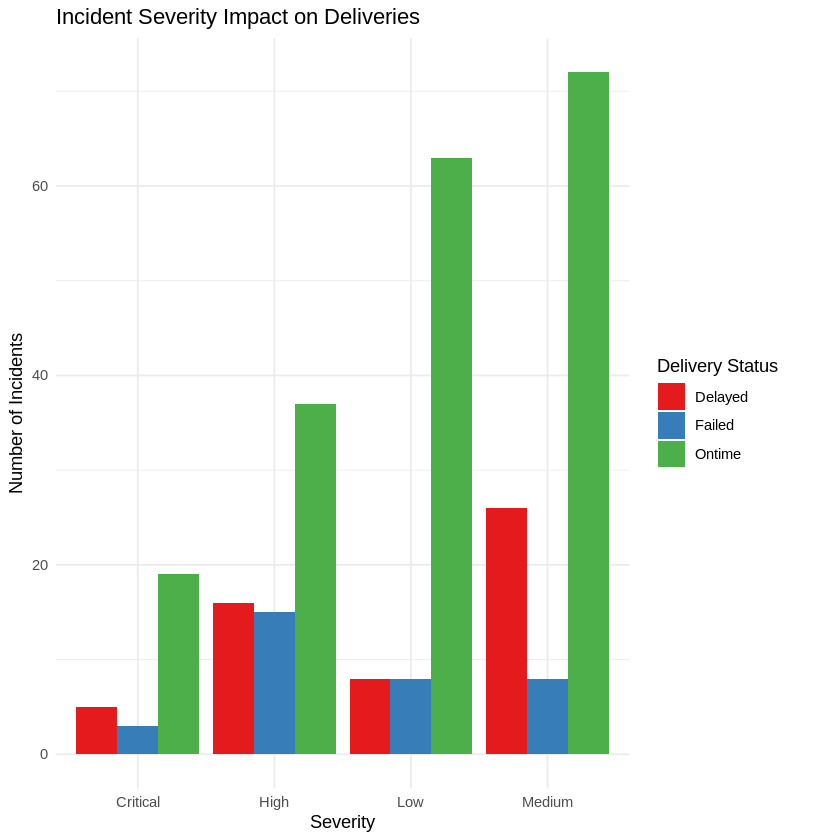

In [10]:
#-------------------GRAPH 6 — INCIDENT IMPACT ON DELIVERY-----------------------

#1 Incident severity impact
incident_kpi <- DELIVERY %>%
  inner_join(INCIDENT, by = "delivery_id") %>%
  group_by(delivery_status, severity) %>%
  summarise(total = n(), .groups = "drop")

#2 Plot incident impact
p6 <- ggplot(incident_kpi, aes(x = severity, y = total, fill = delivery_status)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_brewer(palette = "Set1") +
  labs(
    title = "Incident Severity Impact on Deliveries",
    x = "Severity",
    y = "Number of Incidents",
    fill = "Delivery Status"
  ) +
  theme_minimal()

#3 Display graph
p6

#4 Print insight
cat("Insight: Incident severity is connected with delivery outcomes, especially delayed and failed deliveries.\n")
cat("This shows that operational incidents are important when explaining service disruption.\n")

In [11]:
#-----------------------------SAVE ALL GRAPHS---------------------------------

#1 Save all plots as PNG files
ggsave("Graph1_Delivery_Performance.png", plot = p1, width = 7, height = 5)
ggsave("Graph2_Hub_Failure_Rate.png", plot = p2, width = 7, height = 5)
ggsave("Graph3_Driver_Risk.png", plot = p3, width = 7, height = 5)
ggsave("Graph4_Complaint_Impact.png", plot = p4, width = 7, height = 5)
ggsave("Graph5_Vehicle_Impact.png", plot = p5, width = 7, height = 5)
ggsave("Graph6_Incident_Impact.png", plot = p6, width = 7, height = 5)